# 3D localization from biased range measurements

Estimate a receiver's 3D position $\mathbf{x}$ from noisy ranges to known anchors $\{\mathbf{a}_i\}$, where every measurement carries the **same unknown additive bias** $b$ (e.g., a clock offset in a TDOA-style setup):

$$d_i \;=\; \|\mathbf{x} - \mathbf{a}_i\| \;+\; b \;+\; n_i, \qquad n_i \sim \mathcal{N}(0, \sigma^{2}),\quad i = 1, \dots, N.$$

The three things to handle: the unknown position $\mathbf{x}$, the unknown bias $b$, and the measurement noise $n_i$.

#### What this notebook builds

Two maximum-likelihood solvers — shown to be mathematically equivalent, and verified to agree to floating-point precision:

- **`localize`** — *cancels* the bias by differencing each range against a chosen reference anchor, then refine with Levenberg–Marquardt on the bias-free differenced residuals.

- **`localize_joint`** — *parameterizes* the bias as an extra unknown alongside $\mathbf{x}$ and minimize over $(\mathbf{x}, b)$ jointly. The original noise is i.i.d., so the cost is plain unweighted least-squares — at the price of one extra unknown.

Both iterative solvers are bootstrapped by the closed-form **Schau–Robinson** linear initialization in `linear_init`.

#### Roadmap

1. **Closed-form linear initialization (Schau–Robinson)** — algebraic derivation, `linear_init`.
2. **LM refinement, parts 1–3** — first-principles walkthrough: residual, derivation of $\Sigma$, cost as negative log-likelihood, linearization, Gauss–Newton step, LM damping, asymptotic-ridge trust-region cap.
3. **`localize`** — the differencing-based estimator.
4. **Direct approach** — bias-as-parameter discussion + `localize_joint`.
5. **Demo & Monte Carlo** — anchors on the vertices of a cuboid with survey noise, 2000-trial MC, error histogram.

> All math is built up from the assumed model — variance/covariance refresher and multivariate-Gaussian density included — so the derivations are self-contained.


### Closed-form linear initialization (Schau–Robinson)

**Notation.**

- $\mathbf{x} \in \mathbb{R}^{3}$ — unknown position to estimate.
- $\mathbf{a}_i \in \mathbb{R}^{3}$ — known position of the $i$-th anchor, $i = 1, \dots, N$.
- $\mathbf{a}_\text{ref}$ — chosen reference anchor (one of the $\mathbf{a}_i$); its index is the `ref` argument.
- $d_i$ — measured range from $\mathbf{x}$ to $\mathbf{a}_i$, sharing an unknown additive bias $b$: $d_i = \|\mathbf{x} - \mathbf{a}_i\| + b + n_i$.
- $\delta_i := d_i - d_\text{ref}$ — range *difference*. The bias $b$ cancels, so $\delta_i \approx \|\mathbf{x} - \mathbf{a}_i\| - \|\mathbf{x} - \mathbf{a}_\text{ref}\|$ (up to differenced noise).

Starting from the (noise-free) range-difference identity for each non-reference anchor $i$,

$$\|\mathbf{x} - \mathbf{a}_i\| \;=\; \|\mathbf{x} - \mathbf{a}_\text{ref}\| + \delta_i.$$

**Square both sides:**

$$\|\mathbf{x} - \mathbf{a}_i\|^{2} \;=\; \|\mathbf{x} - \mathbf{a}_\text{ref}\|^{2} \;+\; 2\,\delta_i\,\|\mathbf{x} - \mathbf{a}_\text{ref}\| \;+\; \delta_i^{2}.$$

**Expand the squared norms** via $\|\mathbf{x} - \mathbf{a}\|^{2} = \mathbf{x}^{\!\top}\mathbf{x} - 2\,\mathbf{a}^{\!\top}\mathbf{x} + \|\mathbf{a}\|^{2}$:

$$\mathbf{x}^{\!\top}\mathbf{x} - 2\,\mathbf{a}_i^{\!\top}\mathbf{x} + \|\mathbf{a}_i\|^{2} \;=\; \mathbf{x}^{\!\top}\mathbf{x} - 2\,\mathbf{a}_\text{ref}^{\!\top}\mathbf{x} + \|\mathbf{a}_\text{ref}\|^{2} \;+\; 2\,\delta_i\,R \;+\; \delta_i^{2},$$

where $R := \|\mathbf{x} - \mathbf{a}_\text{ref}\|$. The quadratic term $\mathbf{x}^{\!\top}\mathbf{x}$ **cancels on both sides**. Collect $\mathbf{x}$- and $R$-terms on the left:

$$2\,(\mathbf{a}_\text{ref} - \mathbf{a}_i)^{\!\top}\,\mathbf{x} \;-\; 2\,\delta_i\,R \;=\; \delta_i^{2} + \|\mathbf{a}_\text{ref}\|^{2} - \|\mathbf{a}_i\|^{2}.$$

This is **linear** in the unknowns $(\mathbf{x},\,R)$. Stack one row per non-reference anchor into

$$\underbrace{\begin{bmatrix} 2\,(\mathbf{a}_\text{ref} - \mathbf{a}_i)^{\!\top} & -2\,\delta_i \\ \vdots & \vdots \end{bmatrix}}_{M}\begin{bmatrix} \mathbf{x} \\ R \end{bmatrix} \;=\; \underbrace{\begin{bmatrix} \delta_i^{2} + \|\mathbf{a}_\text{ref}\|^{2} - \|\mathbf{a}_i\|^{2} \\ \vdots \end{bmatrix}}_{\mathbf{b}},$$

and solve $M\,[\mathbf{x};\,R] = \mathbf{b}$ in the least-squares sense. The first three components give the initial position estimate $\mathbf{x}_0$, used to seed the Levenberg–Marquardt refinement.


In [139]:
import numpy as np

def build_differences(d, anchors, ref=0):
    """Form range differences relative to a reference anchor."""
    idx = [i for i in range(len(d)) if i != ref]
    delta = d[idx] - d[ref]                       # (N-1,)
    A_other = anchors[idx]                        # (N-1, 3)
    A_ref = anchors[ref]                          # (3,)
    return delta, A_other, A_ref, idx


def linear_init(d, anchors, ref=0):
    """Closed-form initial position estimate from range differences.

    See the markdown cell above for the derivation. Returns the first three
    components of the least-squares solution to the stacked linear system.
    """
    delta, A_other, a_ref, _ = build_differences(d, anchors, ref)

    M = np.hstack([2.0 * (a_ref - A_other),                       # (N-1, 3)
                   -2.0 * delta.reshape(-1, 1)])                  # (N-1, 1)
    rhs = delta**2 + (a_ref @ a_ref) - np.einsum('ij,ij->i', A_other, A_other)

    sol, *_ = np.linalg.lstsq(M, rhs, rcond=None)
    x0 = sol[:3]
    return x0

### Levenberg–Marquardt refinement (from first principles)

The closed-form `linear_init` gives us a *starting guess* $\mathbf{x}_0$. It's not great — squaring distorts the noise, and there is no notion of *how much we trust each measurement* in that derivation. We now refine it by directly tackling the maximum-likelihood problem.

#### 1. What does it mean for a guess $\mathbf{x}$ to be "good"?

For any candidate position $\mathbf{x}$, define the **residual** for each non-reference anchor $i$:

$$r_i(\mathbf{x}) \;=\; \underbrace{\delta_i}_{\text{measured difference}} \;-\; \underbrace{\bigl(\|\mathbf{x}-\mathbf{a}_i\| - \|\mathbf{x}-\mathbf{a}_\text{ref}\|\bigr)}_{\text{difference predicted by the guess }\mathbf{x}}.$$

If $\mathbf{x}$ were exactly right *and* there were no noise, $r_i$ would be zero for every $i$. With noise, $r_i$ is exactly the **differenced noise** $n_i - n_\text{ref}$ at the true $\mathbf{x}$. So the residual vector $\mathbf{r}(\mathbf{x}) \in \mathbb{R}^{N-1}$ measures how much our guess fails to explain the data.

#### 2. Statistics of the residual — deriving $\Sigma$

##### Quick refresher: variance, covariance, covariance matrix

For a scalar random variable $X$ with mean $\mu_X = \mathbb{E}[X]$, the **variance** is the expected squared deviation from the mean:

$$\mathrm{Var}(X) \;:=\; \mathbb{E}\!\bigl[(X-\mu_X)^{2}\bigr].$$

It measures *spread*: how far $X$ typically falls from its mean. For our model $n_k\sim\mathcal{N}(0,\sigma^{2})$, $\mu_{n_k} = 0$ and $\mathrm{Var}(n_k) = \sigma^{2}$.

For two scalar variables $X, Y$, the **covariance** is the expected product of deviations:

$$\mathrm{Cov}(X, Y) \;:=\; \mathbb{E}\!\bigl[(X-\mu_X)(Y-\mu_Y)\bigr].$$

It measures *co-movement*: positive if $X, Y$ tend to deviate from their means in the *same* direction, negative if opposite, zero if the deviations are unrelated. Some properties we'll lean on:

- $\mathrm{Cov}(X, X) = \mathrm{Var}(X)$.
- **Symmetry**: $\mathrm{Cov}(X, Y) = \mathrm{Cov}(Y, X)$.
- **Bilinearity** (the workhorse): $\mathrm{Cov}(aA+bB,\;cC+dD) = ac\,\mathrm{Cov}(A,C) + ad\,\mathrm{Cov}(A,D) + bc\,\mathrm{Cov}(B,C) + bd\,\mathrm{Cov}(B,D)$.
- **Independence implies zero covariance**: if $X, Y$ are independent, $\mathrm{Cov}(X, Y) = 0$.

For a *vector* random variable $\mathbf{r}\in\mathbb{R}^{m}$ with mean $\mathbb{E}[\mathbf{r}]$, the **covariance matrix** $\Sigma$ collects all pairwise covariances:

$$\Sigma \;:=\; \mathbb{E}\!\bigl[(\mathbf{r}-\mathbb{E}[\mathbf{r}])(\mathbf{r}-\mathbb{E}[\mathbf{r}])^{\!\top}\bigr], \qquad \Sigma_{ij} \;=\; \mathrm{Cov}(r_i, r_j).$$

So $\Sigma$ is an $m\times m$ symmetric (positive semi-definite) matrix whose **diagonal entries are variances** of each component and **off-diagonals are pairwise covariances**. Diagonal $\Sigma$ ⇔ components uncorrelated; off-diagonals encode coupling between components.

##### Computing $\Sigma$ for our differenced residual

We start from the model assumption: each measurement noise $n_k \sim \mathcal{N}(0, \sigma^{2})$ is independent across anchors. At the true position, the $i$-th residual is the differenced noise

$$r_i \;=\; n_i - n_\text{ref}.$$

Since linear combinations of jointly Gaussian variables are Gaussian, the residual vector $\mathbf{r}\in\mathbb{R}^{N-1}$ is jointly Gaussian with mean $\mathbf{0}$. To pin down the covariance $\Sigma$ we just need its entries.

**Diagonal** (variance of one residual). Using $\mathrm{Var}(A \pm B) = \mathrm{Var}(A) + \mathrm{Var}(B)$ for independent $A, B$,

$$\Sigma_{ii} \;=\; \mathrm{Var}(n_i - n_\text{ref}) \;=\; \mathrm{Var}(n_i) + \mathrm{Var}(n_\text{ref}) \;=\; \sigma^{2} + \sigma^{2} \;=\; 2\sigma^{2}.$$

**Off-diagonal** (covariance of two distinct residuals, $i \neq j$). Expand bilinearly and use independence of distinct $n_k$:

$$\Sigma_{ij} \;=\; \mathrm{Cov}(n_i - n_\text{ref},\; n_j - n_\text{ref}) \;=\; \underbrace{\mathrm{Cov}(n_i, n_j)}_{=\,0} \;-\; \underbrace{\mathrm{Cov}(n_i, n_\text{ref})}_{=\,0} \;-\; \underbrace{\mathrm{Cov}(n_\text{ref}, n_j)}_{=\,0} \;+\; \underbrace{\mathrm{Var}(n_\text{ref})}_{=\,\sigma^{2}} \;=\; \sigma^{2}.$$

The off-diagonal term is **not zero** because every residual shares the same $n_\text{ref}$ — that shared term is what couples them. So $\Sigma$ has $2\sigma^{2}$ on the diagonal and $\sigma^{2}$ everywhere else, which factors cleanly as

$$\Sigma \;=\; \sigma^{2}\,\bigl(I + \mathbf{1}\mathbf{1}^{\!\top}\bigr).$$

The two terms have a clean physical reading: $\sigma^{2}\,I$ is each residual's *own* private noise from $n_i$ (independent across $i$); $\sigma^{2}\,\mathbf{1}\mathbf{1}^{\!\top}$ is the *shared* contribution from $n_\text{ref}$ leaking into every residual identically.

##### Probability density of the residual

$$p(\mathbf{r}\mid\mathbf{x}) \;\propto\; \exp\!\left(-\tfrac{1}{2}\,\mathbf{r}(\mathbf{x})^{\!\top}\,\Sigma^{-1}\,\mathbf{r}(\mathbf{x})\right).$$

The "$\mid\mathbf{x}$" reflects that we're treating $\mathbf{x}$ as a parameter: for each candidate $\mathbf{x}$ we compute $\mathbf{r}(\mathbf{x})$ from the data and ask "if $\mathbf{x}$ really were the true position, how plausible would observing this residual be?"

#### 3. From likelihood to cost

The **maximum-likelihood estimate** is the $\mathbf{x}$ that makes the observed residual most probable:

$$\hat{\mathbf{x}} \;=\; \arg\max_{\mathbf{x}}\, p(\mathbf{r}(\mathbf{x})\mid\mathbf{x}) \;=\; \arg\min_{\mathbf{x}}\; \underbrace{\tfrac{1}{2}\,\mathbf{r}(\mathbf{x})^{\!\top}\,W\,\mathbf{r}(\mathbf{x})}_{=:\,C(\mathbf{x})}, \qquad W := \Sigma^{-1}.$$

Three ways to read $C(\mathbf{x})$:

- **Statistically**: negative log-likelihood (up to a constant). Minimizing $C$ *is* maximum likelihood.
- **Geometrically**: a smooth scalar height function over $\mathbb{R}^{3}$. We're descending it.
- **As weighted least-squares**: penalize each residual by how *informative* it is — directions hammered by the shared $n_\text{ref}$ noise get less weight, others more.

The factor $\tfrac{1}{2}$ is cosmetic; it makes the gradient cleaner. Now we have a smooth scalar function $C : \mathbb{R}^{3} \to \mathbb{R}$ to minimize — the next cell tackles *how*.


### LM refinement, part 2 — from cost surface to Gauss–Newton step

#### 4. Why the problem is hard

We want $\nabla C(\mathbf{x}) = \mathbf{0}$. But $\mathbf{r}(\mathbf{x})$ contains Euclidean norms $\|\mathbf{x}-\mathbf{a}_i\|$, so $C$ is nonlinear and the stationarity condition has no closed-form solution. We have to iterate: start from $\mathbf{x}_0$, build a sequence $\mathbf{x}_0,\mathbf{x}_1,\dots$ that decreases $C$.

The only general way to do this is to **approximate $C$ near the current iterate by something we *can* solve**, take the minimizer of the approximation as the next iterate, and repeat.

#### 5. Step 1 — Linearize the residual

Around the current $\mathbf{x}$, take a first-order Taylor expansion of $\mathbf{r}$:

$$\mathbf{r}(\mathbf{x} + \Delta\mathbf{x}) \;\approx\; \mathbf{r}(\mathbf{x}) \;+\; J(\mathbf{x})\,\Delta\mathbf{x},$$

where the **Jacobian** $J \in \mathbb{R}^{(N-1)\times 3}$ has rows

$$\bigl[J\bigr]_{i,:} \;=\; \frac{\partial r_i}{\partial \mathbf{x}}.$$

To compute these rows, recall $\partial \|\mathbf{x}-\mathbf{a}\|/\partial \mathbf{x} = \hat{\mathbf{u}}_a$, the unit vector pointing from $\mathbf{a}$ towards $\mathbf{x}$. So

$$\frac{\partial r_i}{\partial \mathbf{x}} \;=\; -\hat{\mathbf{u}}_i + \hat{\mathbf{u}}_\text{ref}.$$

**Geometry of $J$.** Each row is the difference of two line-of-sight unit vectors. It points along the direction in which a small move of $\mathbf{x}$ changes the *difference of distances* most rapidly. If $\mathbf{x}$ happens to lie almost on the line through $\mathbf{a}_i$ and $\mathbf{a}_\text{ref}$, the two unit vectors nearly coincide and that row collapses to zero — measurement $i$ becomes locally uninformative (geometric dilution of precision).

#### 6. Step 2 — Plug the linearization into the cost

Substitute the linearized residual into $C(\mathbf{x}+\Delta\mathbf{x})$ and expand:

$$C(\mathbf{x}+\Delta\mathbf{x}) \;\approx\; \tfrac{1}{2}\,(\mathbf{r}+J\Delta\mathbf{x})^{\!\top}\,W\,(\mathbf{r}+J\Delta\mathbf{x}) \;=\; \underbrace{\tfrac{1}{2}\mathbf{r}^{\!\top}W\mathbf{r}}_{C(\mathbf{x})} \;+\; \mathbf{g}^{\!\top}\Delta\mathbf{x} \;+\; \tfrac{1}{2}\,\Delta\mathbf{x}^{\!\top}\,H\,\Delta\mathbf{x},$$

with

$$\boxed{\;\mathbf{g} \;:=\; J^{\!\top} W\,\mathbf{r}, \qquad H \;:=\; J^{\!\top} W J.\;}$$

We've turned a hard nonlinear minimization into a **quadratic in $\Delta\mathbf{x}$** — and quadratics we *can* minimize.

#### 7. Step 3 — Minimize the quadratic (Gauss–Newton step)

A quadratic $\tfrac{1}{2}\Delta\mathbf{x}^{\!\top} H\,\Delta\mathbf{x} + \mathbf{g}^{\!\top}\Delta\mathbf{x}$ is minimized where its derivative vanishes:

$$H\,\Delta\mathbf{x} + \mathbf{g} = \mathbf{0} \;\;\Longrightarrow\;\; \Delta\mathbf{x} \;=\; -H^{-1}\mathbf{g}.$$

This is the **Gauss–Newton step**. Geometrically: we replaced the curved cost surface with the best-fitting paraboloid at the current point, and jumped to that paraboloid's minimum. We update $\mathbf{x} \leftarrow \mathbf{x} + \Delta\mathbf{x}$ and repeat.


### LM refinement, part 3 — from Gauss–Newton to Levenberg–Marquardt

#### 8. Why "Gauss–Newton" Hessian?

A pure Newton method would use the **exact** Hessian of $C$:

$$\nabla^{2} C \;=\; \underbrace{J^{\!\top} W J}_{H,\text{ keep}} \;+\; \underbrace{\sum_{i} (W\mathbf{r})_i\,\frac{\partial^{2} r_i}{\partial\mathbf{x}\partial\mathbf{x}^{\!\top}}}_{\text{drop}}.$$

The dropped sum involves second derivatives of the residuals, weighted by the residuals themselves. Near the solution residuals are small (order $\sigma$), so the dropped term is small relative to what we keep. **Gauss–Newton** is exactly this approximation: $\nabla^{2} C \approx J^{\!\top} W J$.

Two side benefits we didn't have to engineer for:

- $H = J^{\!\top} W J$ is always **positive semi-definite** (sandwich form, $W$ PSD), so $-H^{-1}\mathbf{g}$ always points *downhill*.
- Computing $H$ requires only $J$ — which we already need for $\mathbf{g}$. No second-derivative tensors.

#### 9. Why we can't just use Gauss–Newton

The Gauss–Newton step is the minimizer of a *linearization*. That linearization is only accurate near the current $\mathbf{x}$. If $\Delta\mathbf{x}$ is large, $\mathbf{r}(\mathbf{x}+\Delta\mathbf{x})$ may not look anything like $\mathbf{r} + J\Delta\mathbf{x}$, and the "minimizer" can be **worse** than where we started — sometimes catastrophically so. We need a way to *shorten* the step when the linearization seems untrustworthy.

#### 10. The Levenberg–Marquardt fix: damp the step

LM solves a slightly modified linear system:

$$(H + \mu\,I)\,\Delta\mathbf{x} \;=\; -\mathbf{g}.$$

The damping parameter $\mu \ge 0$ smoothly interpolates between two regimes:

- $\mu \to 0$: $\Delta\mathbf{x} \to -H^{-1}\mathbf{g}$ — pure **Gauss–Newton**, large step, fast convergence near the optimum.
- $\mu \to \infty$: $\Delta\mathbf{x} \to -\mathbf{g}/\mu$ — tiny **gradient-descent** step, always reduces $C$ to first order, safest from a bad iterate.

We adapt $\mu$ on the fly:

- Try the step. If $C$ went **down**, the linearization was good — accept and *shrink* $\mu$ (next time be more aggressive). Specifically $\mu \leftarrow \max(\mu/2,\,\mu_{\min})$.
- If $C$ went **up** (or stayed flat), the linearization was bad — reject the step and *grow* $\mu$ ($\mu \leftarrow 4\mu$). This shortens the next step and tilts it toward gradient descent.

The floor $\mu_{\min}$ keeps $H + \mu I$ from going numerically singular when $H$ is rank-deficient.

#### 11. One more safeguard: the asymptotic-ridge runaway

There's a problem specific to TDOA cost surfaces. As $\|\mathbf{x}\|\to\infty$, every line-of-sight unit vector $\hat{\mathbf{u}}_i$ converges to $\mathbf{x}/\|\mathbf{x}\|$, the same for all $i$. So each residual $r_i$ tends to a *finite* limit independent of the radial distance — the cost surface has long, slowly-decaying ridges going to infinity. A bad iterate can latch onto one and walk off to infinity while $C$ decreases by ever-tinier amounts.

Fix: hard-cap each step at the diameter of the anchor cloud,

$$\|\Delta\mathbf{x}\| \;\le\; \mathrm{diam}(\{\mathbf{a}_i\}).$$

This is a poor-man's *trust region* — we simply refuse to consider any step bigger than "the size of the problem".

#### 12. Putting it together

```
x ← linear_init(...)               # closed-form starting guess
loop:
    J ← Jacobian at x
    g ← Jᵀ W r,    H ← Jᵀ W J
    Δx ← solve (H + μI) Δx = −g
    Δx ← clip to anchor diameter
    if C(x + Δx) < C(x):           # accept
        x ← x + Δx
        μ ← max(μ/2, μ_min)
        if ‖Δx‖ < tol: break
    else:                          # reject
        μ ← 4μ
```

#### 13. Free covariance

A perk of working with $H = J^{\!\top} W J$: the **same matrix** that drives the iteration, evaluated at the converged $\hat{\mathbf{x}}$, gives the Cramér–Rao lower bound on the estimator's covariance,

$$\mathrm{Cov}(\hat{\mathbf{x}}) \;\approx\; \bigl(J^{\!\top} W J\bigr)^{-1}.$$

So when we stop, we already have an *uncertainty estimate* for free — that's what populates the `cov` return value.


In [140]:
def localize(d, anchors, sigma=1.0, ref=0, max_iter=50, tol=1e-9, verbose=False):
    """Estimate 3D position from biased ranges with unknown common bias.

    See the LM-refinement markdown cells above for the derivation. When
    ``verbose`` is True, prints a per-iteration trace and plots the cost
    trajectory at the end.

    Parameters
    ----------
    d        : (N,) measured ranges, all sharing an unknown additive bias.
    anchors  : (N, 3) known anchor coordinates.
    sigma    : per-anchor range noise std (used only for weighting).
    ref      : index of reference anchor for differencing.
    max_iter : LM iteration cap.
    tol      : convergence tolerance on step norm.

    Returns
    -------
    x        : (3,) estimated position.
    cov      : (3, 3) estimated covariance of x.
    info     : dict with iteration count and final residual norm.
    """
    
    def residuals(x, d, anchors, ref):
        """Range-difference residuals (bias-free)."""
        delta, A_other, a_ref, _ = build_differences(d, anchors, ref)
        r_ref = np.linalg.norm(x - a_ref)
        r_other = np.linalg.norm(A_other - x, axis=1)
        return delta - (r_other - r_ref)              # (N-1,)

    def jacobian(x, anchors, ref):
        """d(residual_i)/dx = -u_other + u_ref  (see markdown above)."""
        idx = [i for i in range(len(anchors)) if i != ref]
        A_other = anchors[idx]
        a_ref = anchors[ref]

        u_ref = (x - a_ref) / np.linalg.norm(x - a_ref)
        diffs = x - A_other
        u_other = diffs / np.linalg.norm(diffs, axis=1, keepdims=True)
        return -u_other + u_ref                        # (N-1, 3)
    def diff_covariance(n_anchors, ref, sigma=1.0):
        """Covariance of the differenced noise: Sigma = sigma**2 * (I + 11^T)."""
        m = n_anchors - 1
        return sigma**2 * (np.eye(m) + np.ones((m, m)))

    d = np.asarray(d, float)
    anchors = np.asarray(anchors, float)
    N = len(d)
    if N < 4:
        raise ValueError("Need at least 4 anchors (3 independent differences).")

    W = np.linalg.inv(diff_covariance(N, ref, sigma))

    # Closed-form init, then weighted Gauss-Newton cost.
    x = linear_init(d, anchors, ref)
    r = residuals(x, d, anchors, ref)
    cost = 0.5 * r @ W @ r

    cost_history = [cost] if verbose else None
    accept_history = [True] if verbose else None

    # Trust-region cap = anchor-cloud diameter (defeats the asymptotic ridge).
    anchor_scale = float(np.linalg.norm(anchors.max(axis=0) - anchors.min(axis=0)))

    mu, mu_min = 1e-3, 1e-6
    it = 0
    for it in range(max_iter):
        J = jacobian(x, anchors, ref)
        H = J.T @ W @ J
        g = J.T @ W @ r

        dx = np.linalg.solve(H + mu * np.eye(3), -g)
        step_norm = np.linalg.norm(dx)
        if step_norm > anchor_scale:
            dx *= anchor_scale / step_norm
            step_norm = anchor_scale

        x_trial = x + dx
        r_trial = residuals(x_trial, d, anchors, ref)
        cost_trial = 0.5 * r_trial @ W @ r_trial

        if cost_trial < cost:
            x, r, cost = x_trial, r_trial, cost_trial
            mu = max(mu * 0.5, mu_min)
            if verbose:
                print(f"iter {it:2d}  |dx|={step_norm:.3e}  "
                      f"|r|={np.linalg.norm(r):.3e}  mu={mu:.1e}  accept")
                cost_history.append(cost)
                accept_history.append(True)
            if step_norm < tol:
                break
        else:
            mu *= 4.0
            if verbose:
                print(f"iter {it:2d}  |dx|={step_norm:.3e}  "
                      f"cost {cost_trial:.3e} >= {cost:.3e}  mu={mu:.1e}  reject")
                cost_history.append(cost)
                accept_history.append(False)

    # CRLB covariance from the converged (undamped) Hessian.
    J = jacobian(x, anchors, ref)
    cov = np.linalg.pinv(J.T @ W @ J)
    info = {"iterations": it + 1, "residual_norm": float(np.linalg.norm(r))}

    if verbose:
        import matplotlib.pyplot as plt
        history = np.asarray(cost_history)
        accepted = np.asarray(accept_history)
        idx_arr = np.arange(len(history))
        fig, ax = plt.subplots(figsize=(7, 3.2))
        ax.plot(idx_arr, history, color='C0', linewidth=1.5, zorder=1)
        ax.scatter(idx_arr[accepted], history[accepted],
                   color='C2', s=40, label='accept', zorder=2)
        if (~accepted).any():
            ax.scatter(idx_arr[~accepted], history[~accepted],
                       color='C3', marker='x', s=50, label='reject', zorder=2)
        ax.set_xlabel('iteration')
        ax.set_ylabel(r'cost  $C(\mathbf{x}) = \frac{1}{2}\,\mathbf{r}^\top W\,\mathbf{r}$')
        ax.set_title(f'localize: cost trajectory ({info["iterations"]} iters)')
        ax.grid(True, alpha=0.3)
        ax.legend(loc='best')
        plt.show()

    return x, cov, info

### Direct approach — bias as a parameter

The Levenberg–Marquardt machinery from the previous cells operates on **range-difference residuals** — we cancelled the unknown bias $b$ algebraically before iterating. There's an alternative route: **don't cancel $b$ at all**. Treat it as an extra unknown alongside $\mathbf{x}$ and minimize a cost over the raw ranges.

#### Residual

For each anchor $i$, the raw residual is

$$r_i(\mathbf{x}, b) \;=\; d_i \;-\; \|\mathbf{x} - \mathbf{a}_i\| \;-\; b.$$

At the true $(\mathbf{x}, b)$, $r_i = n_i$ — just the original measurement noise. We get $N$ residuals (one per anchor), not $N-1$.

#### Why the noise model is simpler here

Because the $n_i$ are **i.i.d.** $\mathcal{N}(0,\sigma^{2})$ — independent across anchors, with no shared $n_\text{ref}$ — the residual covariance is

$$\Sigma \;=\; \sigma^{2}\,I_N,$$

a plain **diagonal**. No $\mathbf{1}\mathbf{1}^{\!\top}$ correction. The Mahalanobis form $\mathbf{r}^{\!\top}\Sigma^{-1}\mathbf{r}$ collapses to $\tfrac{1}{\sigma^{2}}\|\mathbf{r}\|^{2}$, so the cost reduces to **plain unweighted least-squares**:

$$C(\mathbf{x}, b) \;=\; \tfrac{1}{2}\,\sum_{i=1}^{N} r_i(\mathbf{x}, b)^{2}.$$

(The $\sigma^{2}$ scale is constant in the parameters and drops out of the argmin.)

#### Augmented parameter vector and Jacobian

Stack the unknowns into $\boldsymbol{\theta} := (\mathbf{x}, b) \in \mathbb{R}^{4}$. The Jacobian of $\mathbf{r}$ with respect to $\boldsymbol{\theta}$ has shape $N \times 4$:

$$J(\boldsymbol{\theta}) \;=\; \begin{bmatrix} -\hat{\mathbf{u}}_1^{\!\top} & -1 \\ -\hat{\mathbf{u}}_2^{\!\top} & -1 \\ \vdots & \vdots \\ -\hat{\mathbf{u}}_N^{\!\top} & -1 \end{bmatrix}, \qquad \hat{\mathbf{u}}_i \;:=\; \frac{\mathbf{x} - \mathbf{a}_i}{\|\mathbf{x} - \mathbf{a}_i\|}.$$

Two pieces:
- **First three columns** ($\partial r_i/\partial \mathbf{x} = -\hat{\mathbf{u}}_i$): a single line-of-sight unit vector per row, *not* the difference of two — there's no `ref` term to subtract anymore.
- **Last column** ($\partial r_i/\partial b = -1$): constant. A unit shift in $b$ moves every predicted range by the same amount, so it changes every residual by $-1$.

#### Levenberg–Marquardt step on the augmented system

Same machinery as before, just on $4\times 4$ matrices. With $H := J^{\!\top}J$ (no $W$ in the middle) and $\mathbf{g} := J^{\!\top}\mathbf{r}$,

$$(H + \mu\,I_4)\,\Delta\boldsymbol{\theta} \;=\; -\mathbf{g}, \qquad \boldsymbol{\theta} \;\leftarrow\; \boldsymbol{\theta} + \Delta\boldsymbol{\theta}.$$

The same adaptive-$\mu$ accept/reject rule applies, and we cap the *position part* of $\Delta\boldsymbol{\theta}$ at the anchor-cloud diameter (the asymptotic-ridge runaway lives in the $\mathbf{x}$ subspace, not the $b$ axis).

**Initialization.** $\mathbf{x}_0$ from `linear_init` (which works on differences and is bias-free), then $b_0 = \tfrac{1}{N}\sum_i \bigl(d_i - \|\mathbf{x}_0 - \mathbf{a}_i\|\bigr)$ — the constant shift that best aligns predicted to measured ranges.

**Covariance of the position estimate.** $\mathrm{Cov}(\hat{\boldsymbol{\theta}}) \approx \sigma^{2}(J^{\!\top}J)^{-1}$ at convergence; we return the top-left $3\times 3$ block.

#### Why this gives the same answer as `localize`

The two methods are two parameterizations of the **same maximum-likelihood problem**. Concentrating out (a.k.a. *profiling*) the bias in $C(\mathbf{x}, b)$ — for each fixed $\mathbf{x}$, minimize analytically over $b$ — gives

$$\hat{b}(\mathbf{x}) \;=\; \tfrac{1}{N}\sum_{i=1}^{N}\bigl(d_i - \|\mathbf{x}-\mathbf{a}_i\|\bigr).$$

Substituting back collapses $C$ into a function of $\mathbf{x}$ alone that is *algebraically identical* (up to a constant in $\mathbf{x}$) to the differenced weighted-LS cost — the $(I + \mathbf{1}\mathbf{1}^{\!\top})^{-1}$ weighting falls out of the same projection. So the converged $\hat{\mathbf{x}}$ and the position block of $(J^{\!\top}J)^{-1}$ match `localize` to floating-point precision.

#### Trade-offs at a glance

| | **`localize`** (differencing) | **`localize_joint`** (bias as parameter) |
|--|:--|:--|
| Unknowns | $3$ &nbsp;(just $\mathbf{x}$) | $4$ &nbsp;($\mathbf{x}$ and $b$) |
| Residuals | $N - 1$ | $N$ |
| Noise covariance | $\sigma^{2}(I + \mathbf{1}\mathbf{1}^{\!\top})$ — needs inversion | $\sigma^{2}I$ — diagonal, trivial |
| Cost form | Weighted LS | Plain unweighted LS |
| Anchor minimum | $N \ge 4$ | $N \ge 4$ |
| Hessian size | $3 \times 3$ | $4 \times 4$ |

Mathematically equivalent at the optimum. The raw-residual version is *conceptually cleaner* (no correlated noise to bookkeep); the differencing version is *leaner per iteration* (one fewer unknown, smaller Hessian). Pick whichever fits your taste — and use their agreement as a sanity check.


In [141]:
def localize_joint(d, anchors, sigma=1.0, max_iter=50, tol=1e-9, verbose=False):
    """Estimate (position, bias) jointly from raw biased range measurements.

    See the "Direct approach" markdown cell above for the derivation and
    trade-offs vs. ``localize``. When ``verbose`` is True, prints a
    per-iteration trace and plots the cost trajectory at the end.

    Returns
    -------
    x      : (3,) estimated position.
    b      : float, estimated common bias.
    cov_x  : (3, 3) estimated covariance of x (top-left block of full 4x4).
    info   : dict with iteration count and final residual norm.
    """
    d = np.asarray(d, float)
    anchors = np.asarray(anchors, float)
    N = len(d)
    if N < 4:
        raise ValueError("Need at least 4 anchors to identify (x, b).")

    # Init: x from differences (bias-free), then b from leftover offset.
    x = linear_init(d, anchors)
    b = float(np.mean(d - np.linalg.norm(anchors - x, axis=1)))

    anchor_scale = float(np.linalg.norm(anchors.max(axis=0) - anchors.min(axis=0)))

    def residuals(x, b):
        return d - np.linalg.norm(anchors - x, axis=1) - b

    def jacobian(x):
        diffs = x - anchors                                 # (N, 3)
        u = diffs / np.linalg.norm(diffs, axis=1, keepdims=True)
        return np.hstack([-u, -np.ones((N, 1))])            # (N, 4)

    r = residuals(x, b)
    cost = 0.5 * (r @ r)

    cost_history = [cost] if verbose else None
    accept_history = [True] if verbose else None

    mu, mu_min = 1e-3, 1e-6
    it = 0
    for it in range(max_iter):
        J = jacobian(x)
        H = J.T @ J
        g = J.T @ r

        dtheta = np.linalg.solve(H + mu * np.eye(4), -g)

        # Cap position part of the step.
        dx_norm = np.linalg.norm(dtheta[:3])
        if dx_norm > anchor_scale:
            dtheta *= anchor_scale / dx_norm

        x_trial = x + dtheta[:3]
        b_trial = b + dtheta[3]
        r_trial = residuals(x_trial, b_trial)
        cost_trial = 0.5 * (r_trial @ r_trial)

        if cost_trial < cost:
            x, b, r, cost = x_trial, b_trial, r_trial, cost_trial
            mu = max(mu * 0.5, mu_min)
            if verbose:
                print(f"iter {it:2d}  |dθ|={np.linalg.norm(dtheta):.3e}  "
                      f"|r|={np.linalg.norm(r):.3e}  b={b:.4f}  mu={mu:.1e}  accept")
                cost_history.append(cost)
                accept_history.append(True)
            if np.linalg.norm(dtheta) < tol:
                break
        else:
            mu *= 4.0
            if verbose:
                print(f"iter {it:2d}  |dθ|={np.linalg.norm(dtheta):.3e}  "
                      f"cost {cost_trial:.3e} >= {cost:.3e}  mu={mu:.1e}  reject")
                cost_history.append(cost)
                accept_history.append(False)

    J = jacobian(x)
    cov_x = (sigma**2 * np.linalg.pinv(J.T @ J))[:3, :3]
    info = {"iterations": it + 1, "residual_norm": float(np.linalg.norm(r))}

    if verbose:
        import matplotlib.pyplot as plt
        history = np.asarray(cost_history)
        accepted = np.asarray(accept_history)
        idx_arr = np.arange(len(history))
        fig, ax = plt.subplots(figsize=(7, 3.2))
        ax.plot(idx_arr, history, color='C0', linewidth=1.5, zorder=1)
        ax.scatter(idx_arr[accepted], history[accepted],
                   color='C2', s=40, label='accept', zorder=2)
        if (~accepted).any():
            ax.scatter(idx_arr[~accepted], history[~accepted],
                       color='C3', marker='x', s=50, label='reject', zorder=2)
        ax.set_xlabel('iteration')
        ax.set_ylabel(r'cost  $C(\mathbf{x},b) = \frac{1}{2}\,\|\mathbf{r}\|^2$')
        ax.set_title(f'localize_joint: cost trajectory ({info["iterations"]} iters)')
        ax.grid(True, alpha=0.3)
        ax.legend(loc='best')
        plt.show()

    return x, b, cov_x, info

iter  0  |dx|=2.147e+00  |r|=3.488e-01  mu=5.0e-04  accept
iter  1  |dx|=1.724e-01  |r|=3.656e-01  mu=2.5e-04  accept
iter  2  |dx|=7.639e-04  |r|=3.638e-01  mu=1.3e-04  accept
iter  3  |dx|=6.723e-06  |r|=3.638e-01  mu=6.3e-05  accept


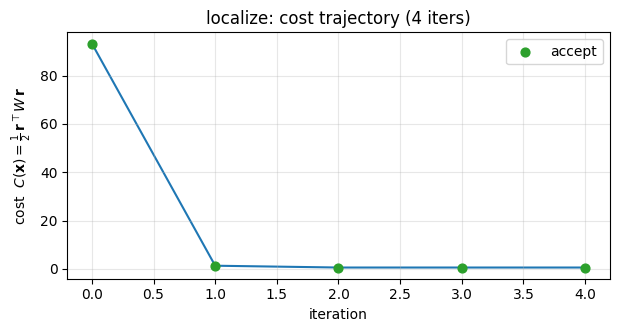

--- localize result ---
true  x : [3.7 4.2 1.9]
init  x : [2.62360535 3.86465754 0.39508726]
est   x : [3.65949495 4.36034696 2.0041612 ]
init err: 1.8804  m
error   : 0.1955  m
1-sigma : [0.1180029  0.11408823 0.15404315]
iters   : 4
iter  0  |dθ|=2.297e+00  |r|=6.389e-01  b=3.2012  mu=5.0e-04  accept
iter  1  |dθ|=2.856e-01  |r|=2.109e-01  b=2.9721  mu=2.5e-04  accept
iter  2  |dθ|=1.439e-03  |r|=2.108e-01  b=2.9709  mu=1.3e-04  accept
iter  3  |dθ|=6.602e-06  |r|=2.108e-01  b=2.9709  mu=6.3e-05  accept


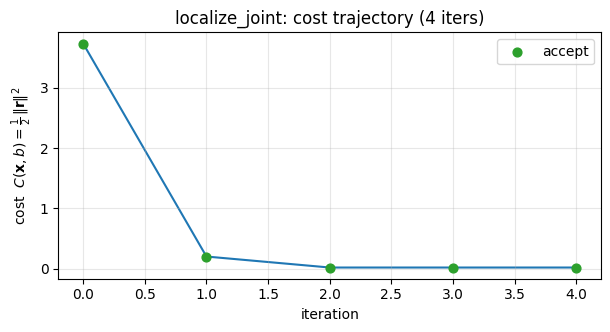

--- localize_joint result ---
true  x : [3.7 4.2 1.9],  b = 3.0
est   x : [3.65949495 4.36034696 2.0041612 ],  b = 2.9709
error   : 0.1955  m
1-sigma : [0.1180029  0.11408823 0.15404315]
iters   : 4

localize vs localize_joint  |Δx| = 3.67e-09  m


In [142]:
# --------------------------------------------------------------------------
# Demo / sanity check
# --------------------------------------------------------------------------
rng = np.random.default_rng(0)

# True anchors on the 8 vertices of a cuboid (W along x, D along y, H along z).
H, W, D = 8.0, 10.0, 10.0
anchors_true = np.array([
    [0.0, 0.0, 0.0],
    [W,   0.0, 0.0],
    [0.0, D,   0.0],
    [W,   D,   0.0],
    [0.0, 0.0, H  ],
    [W,   0.0, H  ],
    [0.0, D,   H  ],
    [W,   D,   H  ],
])

# Anchor placement / survey error: zero-mean Gaussian, drawn once.
# The localizer only knows the noisy surveyed positions; ranges are
# physically generated from the true positions, so the mismatch
# introduces a model bias.
anchor_sigma = 0.1                            # anchor survey std (m)
anchors = anchors_true + rng.normal(0, anchor_sigma, size=anchors_true.shape)

x_true = np.array([3.7, 4.2, 1.9])
bias_true = 3.0                                # unknown common offset
sigma = 0.2                                    # range noise std (m)
tol = 1e-4

# Ranges are physically generated from the TRUE anchor positions.
true_ranges = np.linalg.norm(anchors_true - x_true, axis=1)
d_meas = true_ranges + bias_true + rng.normal(0, sigma, size=len(anchors_true))

# Localizer is given the noisy surveyed anchors.
x0 = linear_init(d_meas, anchors)

x_hat, cov, info = localize(d_meas, anchors, sigma=sigma, tol=tol, verbose=True)
print("--- localize result ---")
print(f"true  x : {x_true}")
print(f"init  x : {x0}")
print(f"est   x : {x_hat}")
print(f"init err: {np.linalg.norm(x0 - x_true):.4f}  m")
print(f"error   : {np.linalg.norm(x_hat - x_true):.4f}  m")
print(f"1-sigma : {np.sqrt(np.diag(cov))}")
print(f"iters   : {info['iterations']}")

# Same data, joint (bias-as-parameter) estimator.
x_hat_j, b_hat_j, cov_j, info_j = localize_joint(d_meas, anchors, sigma=sigma, tol=tol, verbose=True)
print("--- localize_joint result ---")
print(f"true  x : {x_true},  b = {bias_true}")
print(f"est   x : {x_hat_j},  b = {b_hat_j:.4f}")
print(f"error   : {np.linalg.norm(x_hat_j - x_true):.4f}  m")
print(f"1-sigma : {np.sqrt(np.diag(cov_j))}")
print(f"iters   : {info_j['iterations']}")

# Sanity check: the two methods should agree to ~ machine epsilon.
print(f"\nlocalize vs localize_joint  |Δx| = {np.linalg.norm(x_hat - x_hat_j):.2e}  m")

In [143]:
# Monte Carlo: only range noise re-randomizes; anchor survey is fixed.
trials = 2000
errs = np.zeros((trials, 3))
iters = np.zeros(trials, dtype=int)
for k in range(trials):
    d_k = true_ranges + bias_true + rng.normal(0, sigma, size=len(anchors_true))
    anchors = anchors_true + rng.normal(0, anchor_sigma, size=anchors_true.shape)
    x_k, _, _, info_k = localize_joint(d_k, anchors, tol=tol, sigma=sigma)
    errs[k] = x_k - x_true
    iters[k] = info_k['iterations']
print(f"\nMC RMSE per axis: {np.sqrt((errs**2).mean(axis=0))}")
print(f"MC total RMSE   : {np.sqrt((errs**2).sum(axis=1).mean()):.4f}  m")
print(f"iters: min={iters.min()}, median={int(np.median(iters))}, max={iters.max()}")



MC RMSE per axis: [0.12943913 0.12789836 0.17272493]
MC total RMSE   : 0.2509  m
iters: min=2, median=4, max=12


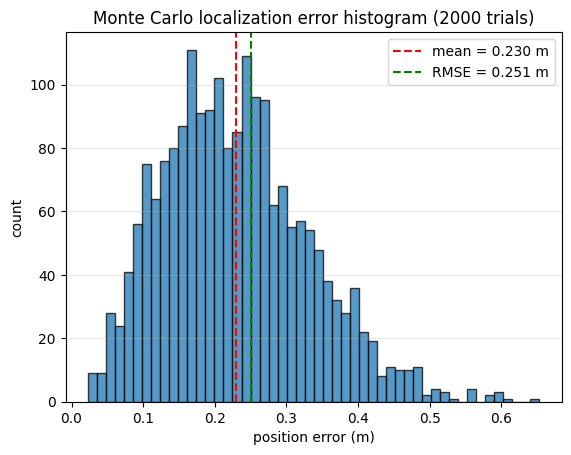

In [144]:
import matplotlib.pyplot as plt

err_norms = np.linalg.norm(errs, axis=1)

plt.figure()
plt.hist(err_norms, bins=50, edgecolor='black', alpha=0.75)
plt.axvline(err_norms.mean(), color='r', linestyle='--', label=f'mean = {err_norms.mean():.3f} m')
plt.axvline(np.sqrt((err_norms**2).mean()), color='g', linestyle='--',
            label=f'RMSE = {np.sqrt((err_norms**2).mean()):.3f} m')
plt.xlabel('position error (m)')
plt.ylabel('count')
plt.title(f'Monte Carlo localization error histogram ({len(errs)} trials)')
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.show()


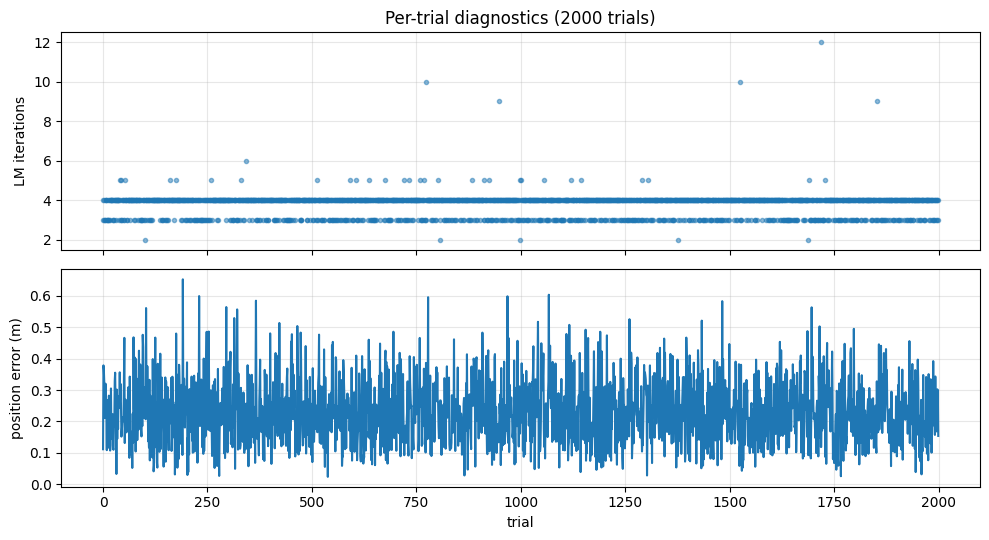

In [145]:
import matplotlib.pyplot as plt

fig, (ax_it, ax_er) = plt.subplots(2, 1, figsize=(10, 5.5), sharex=True)

ax_it.plot(iters, '.', alpha=0.5, color='C0')
ax_it.set_ylabel('LM iterations')
ax_it.set_title(f'Per-trial diagnostics ({len(iters)} trials)')
ax_it.grid(True, alpha=0.3)

ax_er.plot(err_norms, alpha=1.0, color='C0')
ax_er.set_xlabel('trial')
ax_er.set_ylabel('position error (m)')
ax_er.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
